# UECFoodPIX Baselines: ResNet50-FCN and VGG16-FCN

**Objective.** Establish two reproducible CNN semantic-segmentation baselines for COMP9444 Project 005 and compare them on the official held-out UECFoodPIX test set.

**Success criteria.** Both runs must use the supplied leakage-free 3,000/500 train/validation split and the official held-out 1,000-image test set, save a best validation checkpoint, and produce loss/validation curves, accuracy and IoU metrics, a pixel-level confusion matrix, and qualitative predictions.


## 1. Setup and reproducibility

Training was completed on HPC2 GPUs. This executed notebook is deliberately lightweight: it verifies and presents the immutable result artifacts, while the full training implementation remains in `src/`.


In [1]:
from pathlib import Path
import csv, hashlib, json
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
assert (ROOT / "src" / "train.py").exists(), "Run the notebook from the project root"
MODELS = {"resnet50_fcn": "ResNet50-FCN", "vgg16_fcn": "VGG16-FCN"}
SEED = 9444
print(f"Project root: {ROOT}")
print(f"Fixed seed: {SEED}")


Project root: C:\Users\qh\Desktop\lsz\group wk\COMP9444_Project005_Baselines
Fixed seed: 9444


## 2. Evaluation protocol

The group-supplied JSON fixes 3,000 training and 500 validation images, all drawn from the official 9,000-image training set. The official 1,000-image test set is never used for model selection. The best epoch is selected only by validation mean IoU; that checkpoint is then evaluated once on the official test set.


In [2]:
manifest = json.loads((ROOT / "splits" / "split_manifest.json").read_text(encoding="utf-8"))
split_files = {
    "train": ROOT / "splits" / "train_3000.txt",
    "validation": ROOT / "splits" / "val_500.txt",
    "test": ROOT / "splits" / "test_official_1000.txt",
}
ids = {name: set(path.read_text(encoding="utf-8").splitlines()) for name, path in split_files.items()}
assert {name: len(values) for name, values in ids.items()} == {"train": 3000, "validation": 500, "test": 1000}
assert ids["train"].isdisjoint(ids["validation"])
assert ids["train"].isdisjoint(ids["test"])
assert ids["validation"].isdisjoint(ids["test"])
for path in split_files.values():
    assert hashlib.sha256(path.read_bytes()).hexdigest() == manifest["files"][path.name]
source_json = ROOT / "splits" / "uecfoodpix_split_train3000_val500.json"
assert hashlib.sha256(source_json.read_bytes()).hexdigest() == manifest["source_json_sha256"]
print(json.dumps({"counts": {name: len(values) for name, values in ids.items()},
                  "train_validation_overlap": len(ids["train"] & ids["validation"]),
                  "official_test_overlap": len(ids["test"] & (ids["train"] | ids["validation"])),
                  "train_seed": manifest["train_seed"],
                  "validation_seed": manifest["val_seed"],
                  "source_json_sha256": manifest["source_json_sha256"]}, indent=2))


{
  "counts": {
    "train": 3000,
    "validation": 500,
    "test": 1000
  },
  "train_validation_overlap": 0,
  "official_test_overlap": 0,
  "train_seed": 9444,
  "validation_seed": 9445,
  "source_json_sha256": "fed0847e554c1ecf28946f1069f39facaf722192616d6f1fc5a9672f5c336cc4"
}


## 3. Baseline design

- **ResNet50-FCN:** standard torchvision ResNet50 encoder, a 3x3 convolutional projection followed by a 1x1 classifier, and bilinear upsampling.
- **VGG16-FCN:** standard torchvision VGG16 feature encoder, a matching lightweight 3x3 projection plus 1x1 classifier, and bilinear upsampling.
- Both are trained from scratch with AdamW, cross-entropy loss, fixed learning rate, horizontal-flip augmentation, ImageNet normalization, and no scheduler, early stopping, class weighting, or pretrained weights.


In [3]:
configs = {}
for key, label in MODELS.items():
    config = json.loads((ROOT / "outputs" / key / "run_config.json").read_text(encoding="utf-8"))
    configs[key] = config
    print(f"{label}: {config['parameter_count']:,} trainable parameters; "
          f"epochs={config['epochs']}, input={config['image_width']}x{config['image_height']}, "
          f"batch_size={config['batch_size']}, lr={config['lr']}, dropout={config['dropout']}, "
          f"pretrained={config['pretrained_weights']}")
assert configs["resnet50_fcn"]["split_counts"] == configs["vgg16_fcn"]["split_counts"]


ResNet50-FCN: 32,999,079 trainable parameters; epochs=30, input=384x320, batch_size=2, lr=0.0003, dropout=0.2, pretrained=False
VGG16-FCN: 15,921,063 trainable parameters; epochs=30, input=384x320, batch_size=2, lr=0.0003, dropout=0.2, pretrained=False


## 4. Training implementation and exact commands

The full, reusable PyTorch implementation is in `src/models.py`, `src/train.py`, and the two model-specific entry points. HPC2 used resumable long-GPU Slurm jobs; when an eight-hour allocation ended, the next dependent job restored model, optimizer, scaler, history and best-validation state from the last completed epoch. The official test set was not evaluated until all 30 epochs had completed.


In [4]:
print((ROOT / "reproducibility" / "environment.txt").read_text(encoding="utf-8"))
for key, label in MODELS.items():
    command_name = "resnet50_command.txt" if key == "resnet50_fcn" else "vgg16_command.txt"
    command = (ROOT / "reproducibility" / command_name).read_text(encoding="utf-8").strip()
    architecture = (ROOT / "outputs" / key / "model_architecture.txt").read_text(encoding="utf-8")
    print(f"\n{label} exact command:\n{command}")
    print(f"{label} architecture excerpt:\n" + "\n".join(architecture.splitlines()[:18]) + "\n...")


python 3.11.4 (main, Jul  5 2023, 13:45:01) [GCC 11.2.0]
platform Linux-5.4.0-155-generic-x86_64-with-glibc2.31
torch 2.0.1+cu118
torchvision 0.15.2+cu118
cuda_runtime 11.8
numpy 1.24.1
pillow 9.3.0
matplotlib 3.7.2


ResNet50-FCN exact command:
/hpc2ssd/softwares/anaconda3/envs/pytorch_gpu_2.0.1/bin/python src/train.py --model resnet50 --data-root /hpc2hdd/home/hqi881/projects/comp9444_project005_baselines_20260730_chat_protocol/assets/UECFOODPIX/data --split-dir splits --output-dir outputs --epochs 30 --image-width 384 --image-height 320 --batch-size 2 --lr 0.0003 --weight-decay 0.0001 --dropout 0.2 --num-workers 6 --seed 9444 --device cuda --amp --log-every 200 --resume
ResNet50-FCN architecture excerpt:
ResNet50FCN(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2

## 5. Training and validation curves


ResNet50-FCN


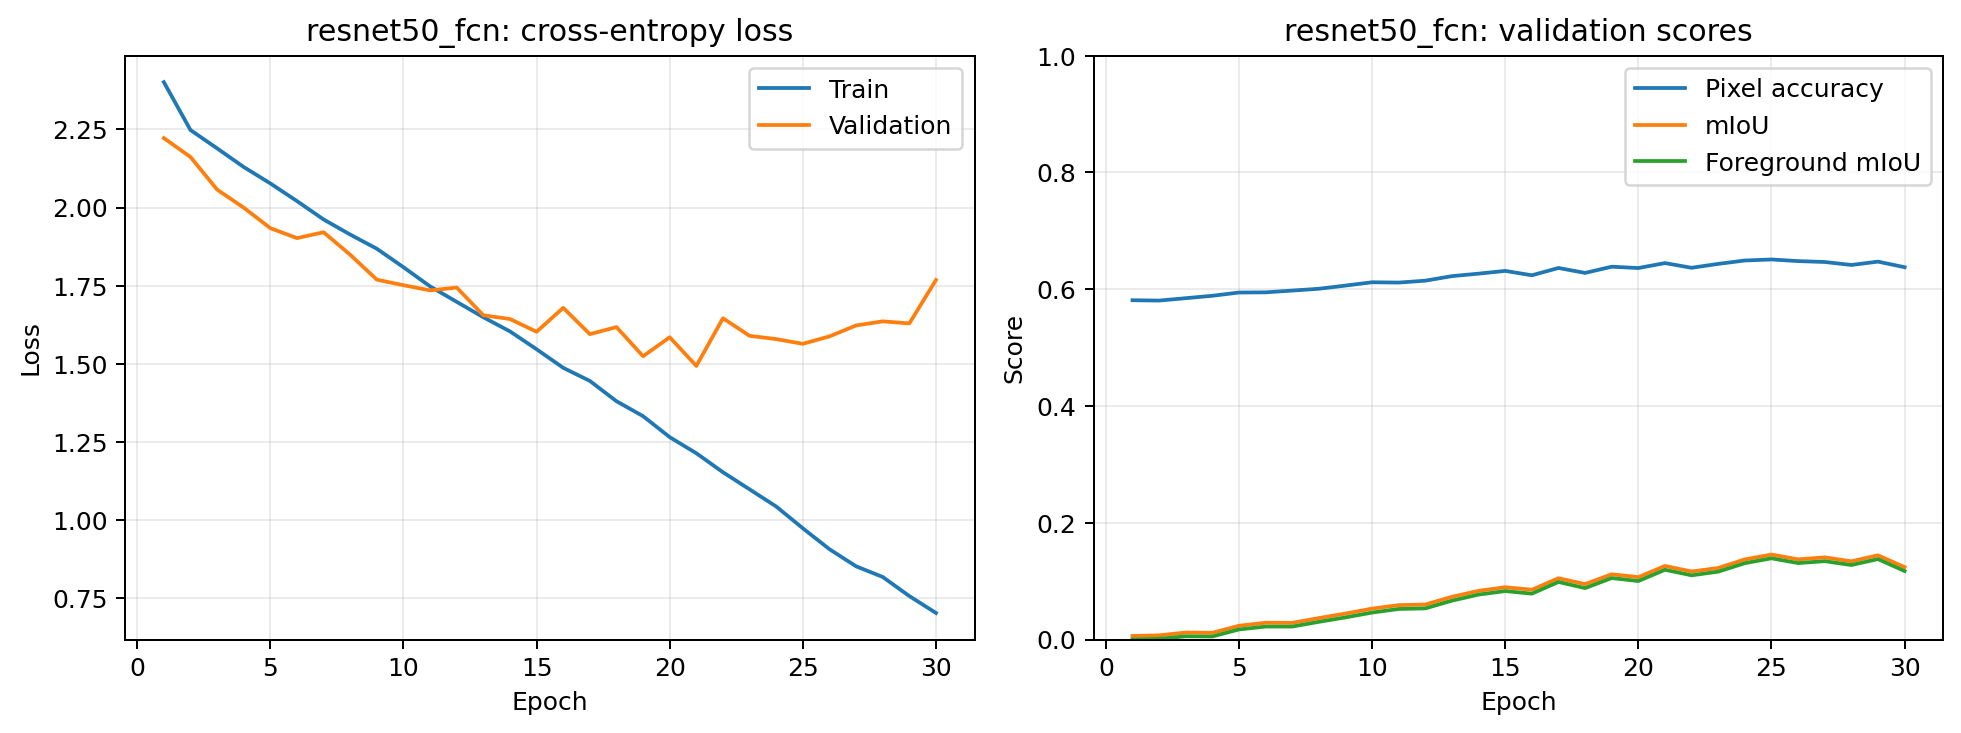

VGG16-FCN


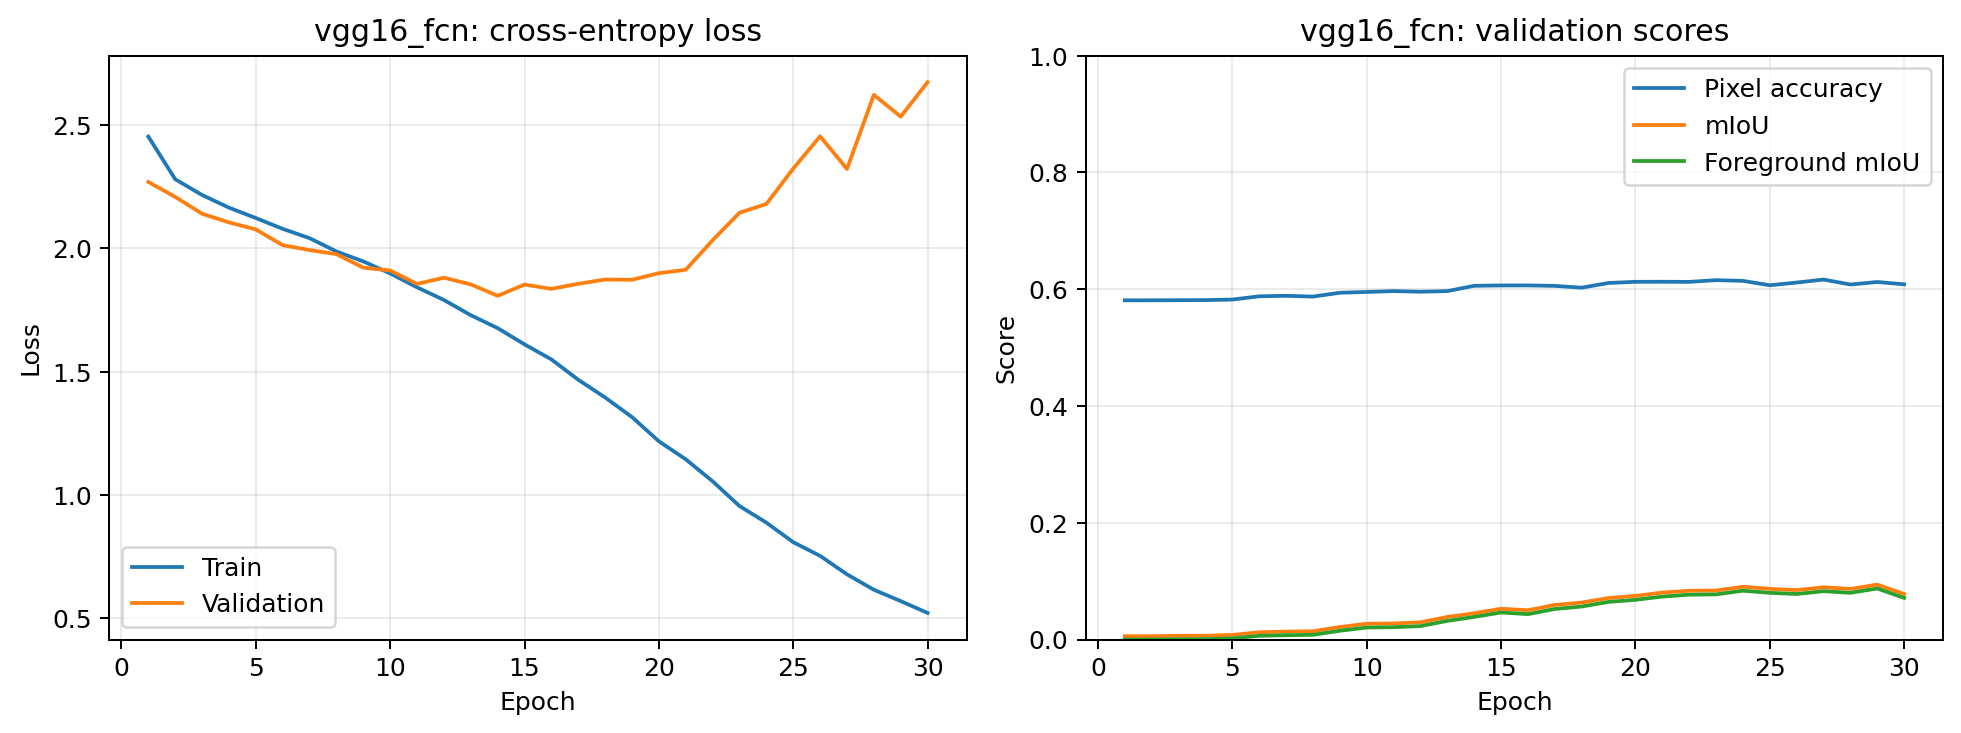

In [5]:
for key, label in MODELS.items():
    print(label)
    display(Image(filename=str(ROOT / "outputs" / key / "training_curves.png"), width=900))


## 6. Official test-set comparison


model        | best_epoch | test_loss | test_pixel_accuracy | test_mIoU | test_foreground_mIoU | test_macro_f1
-------------+------------+-----------+---------------------+-----------+----------------------+--------------
ResNet50-FCN | 25         | 1.7379    | 0.6259              | 0.1178    | 0.1112               | 0.1896       
VGG16-FCN    | 29         | 2.8677    | 0.5896              | 0.0693    | 0.0625               | 0.1128       


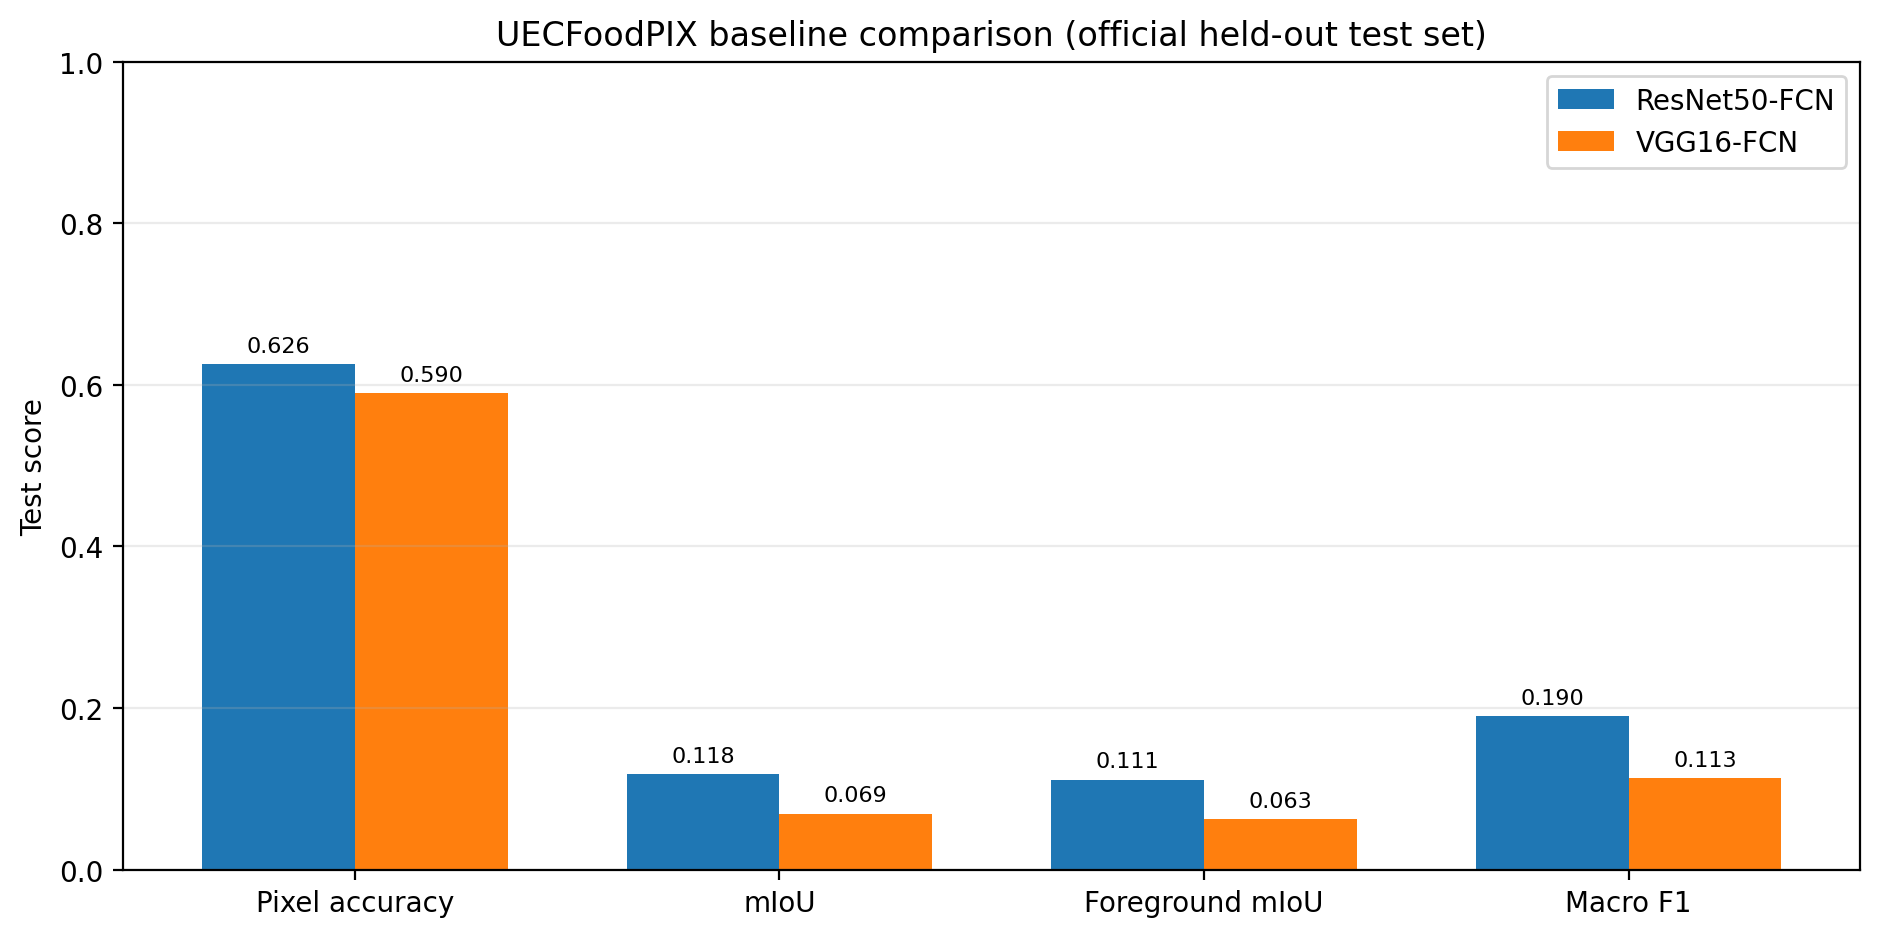

In [6]:
rows = list(csv.DictReader((ROOT / "outputs" / "comparison" / "baseline_results.csv").open(encoding="utf-8", newline="")))
columns = ["model", "best_epoch", "test_loss", "test_pixel_accuracy", "test_mIoU", "test_foreground_mIoU", "test_macro_f1"]
widths = {column: max(len(column), *(len(f"{float(row[column]):.4f}") if column not in {"model", "best_epoch"} else len(str(row[column])) for row in rows)) for column in columns}
def formatted(row, column):
    return str(row[column]) if column in {"model", "best_epoch"} else f"{float(row[column]):.4f}"
print(" | ".join(column.ljust(widths[column]) for column in columns))
print("-+-".join("-" * widths[column] for column in columns))
for row in rows:
    print(" | ".join(formatted(row, column).ljust(widths[column]) for column in columns))
display(Image(filename=str(ROOT / "outputs" / "comparison" / "baseline_comparison.png"), width=900))


### Result interpretation

Under the fixed protocol, **ResNet50-FCN** has the higher test mean IoU (0.1178). Pixel accuracy is reported alongside mean IoU because background pixels are frequent and can make accuracy alone appear optimistic. These are intentionally unoptimised baselines, so they provide a reproducible floor for comparison with the group's improved model rather than a state-of-the-art claim.


## 7. Confusion matrices and qualitative predictions


ResNet50-FCN: all 103 classes plus a normalized detail view of the 25 most-supported classes


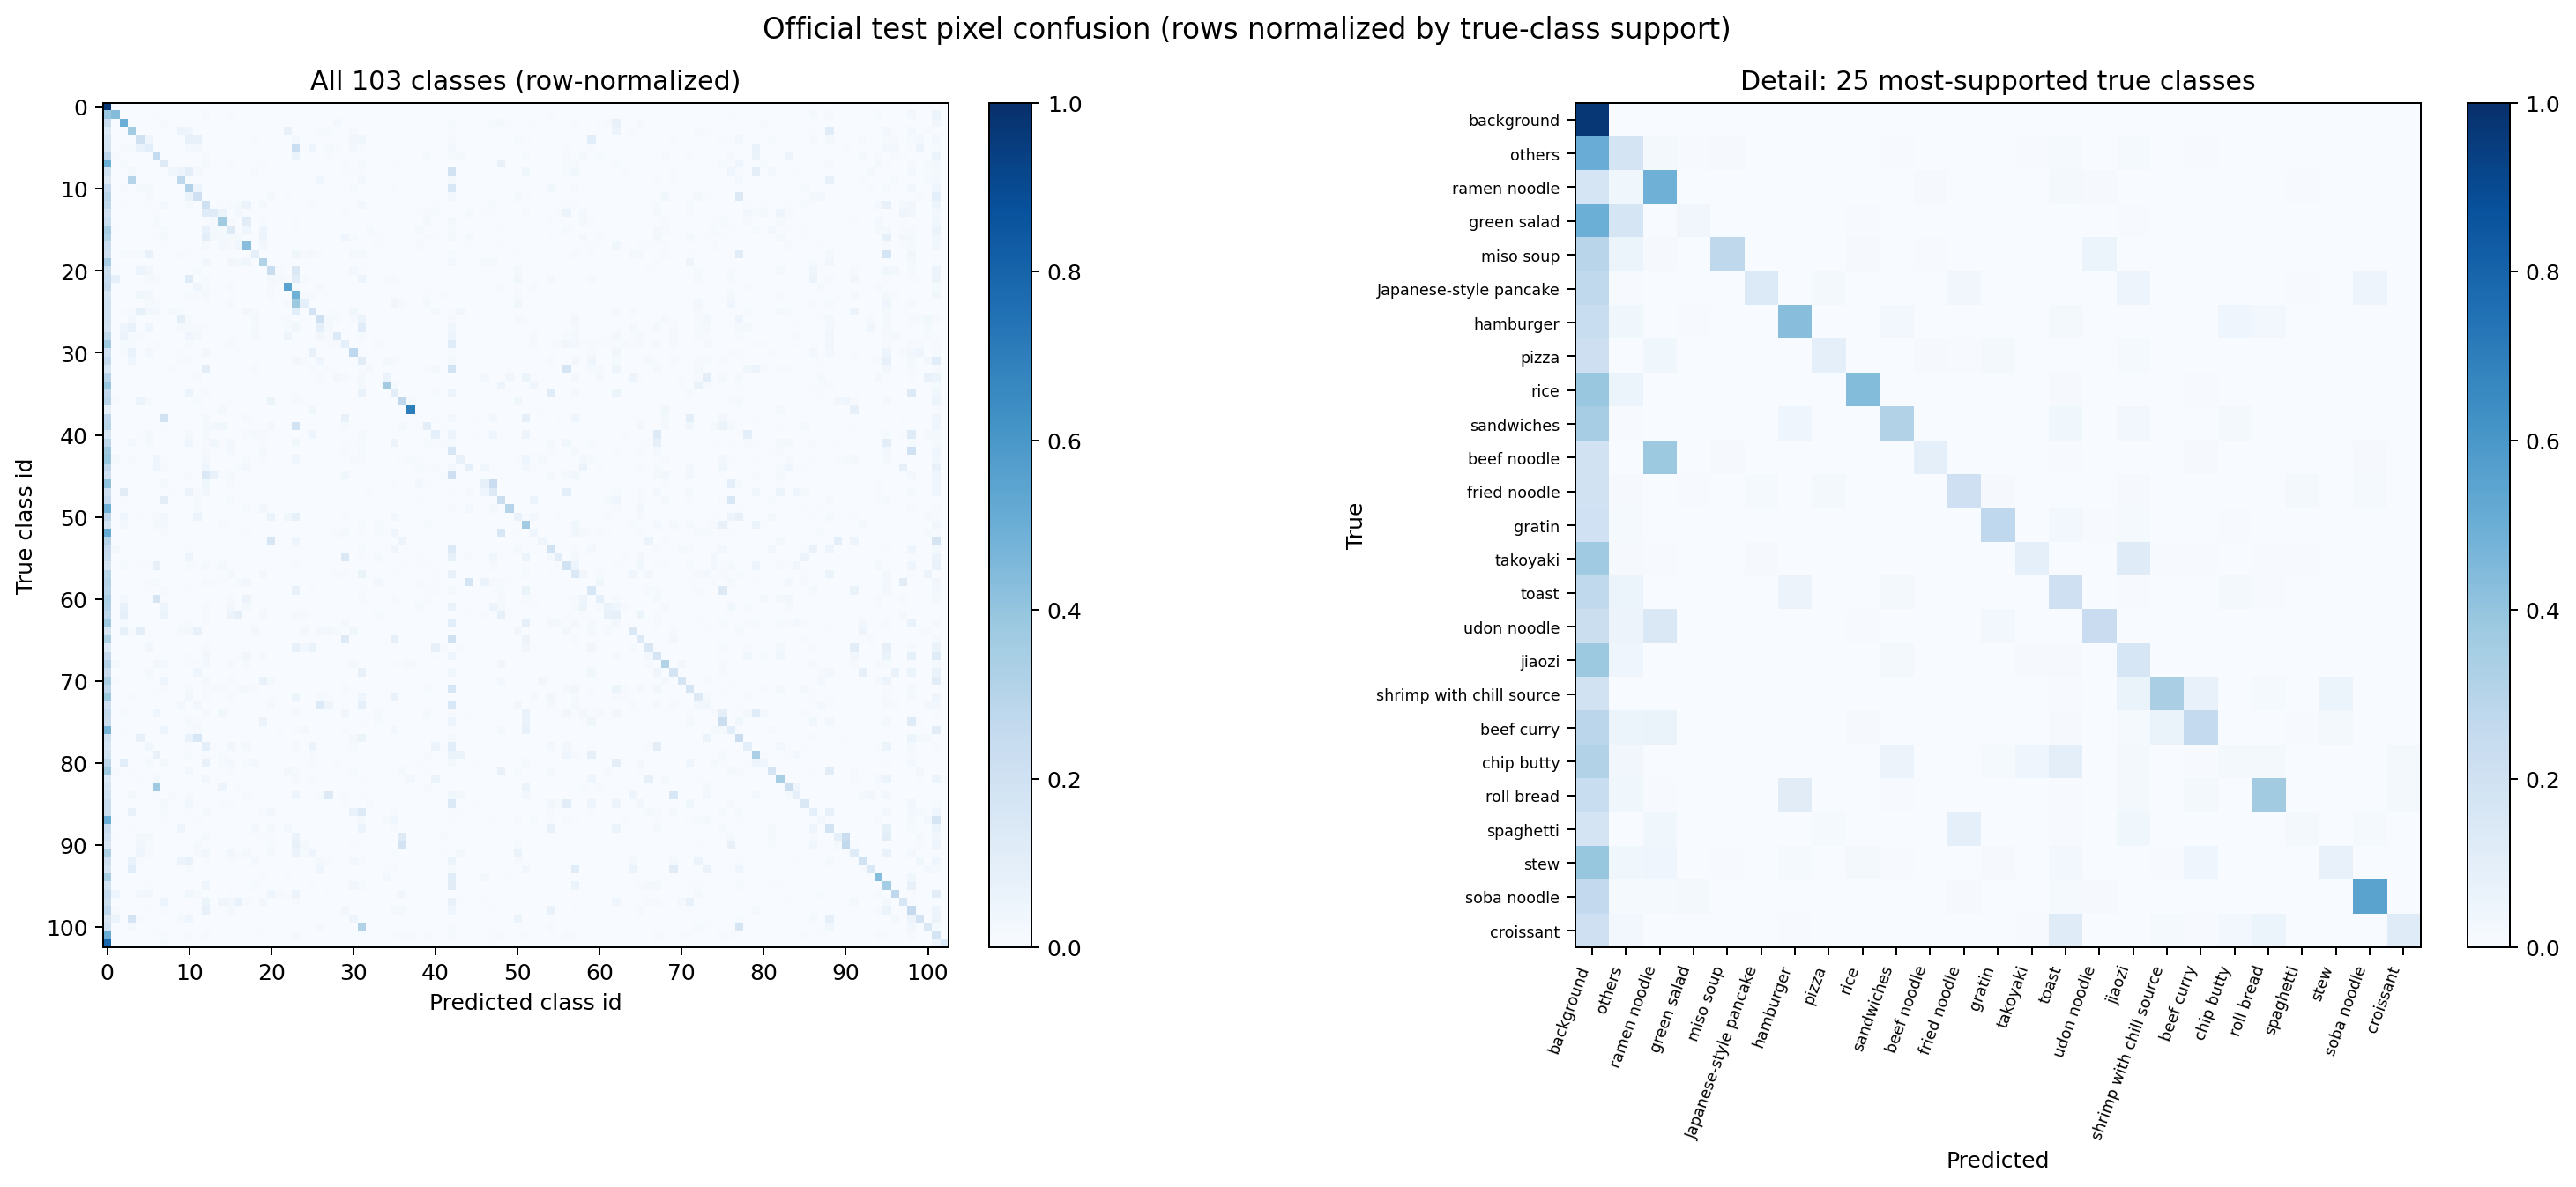

ResNet50-FCN: input / ground truth / prediction examples


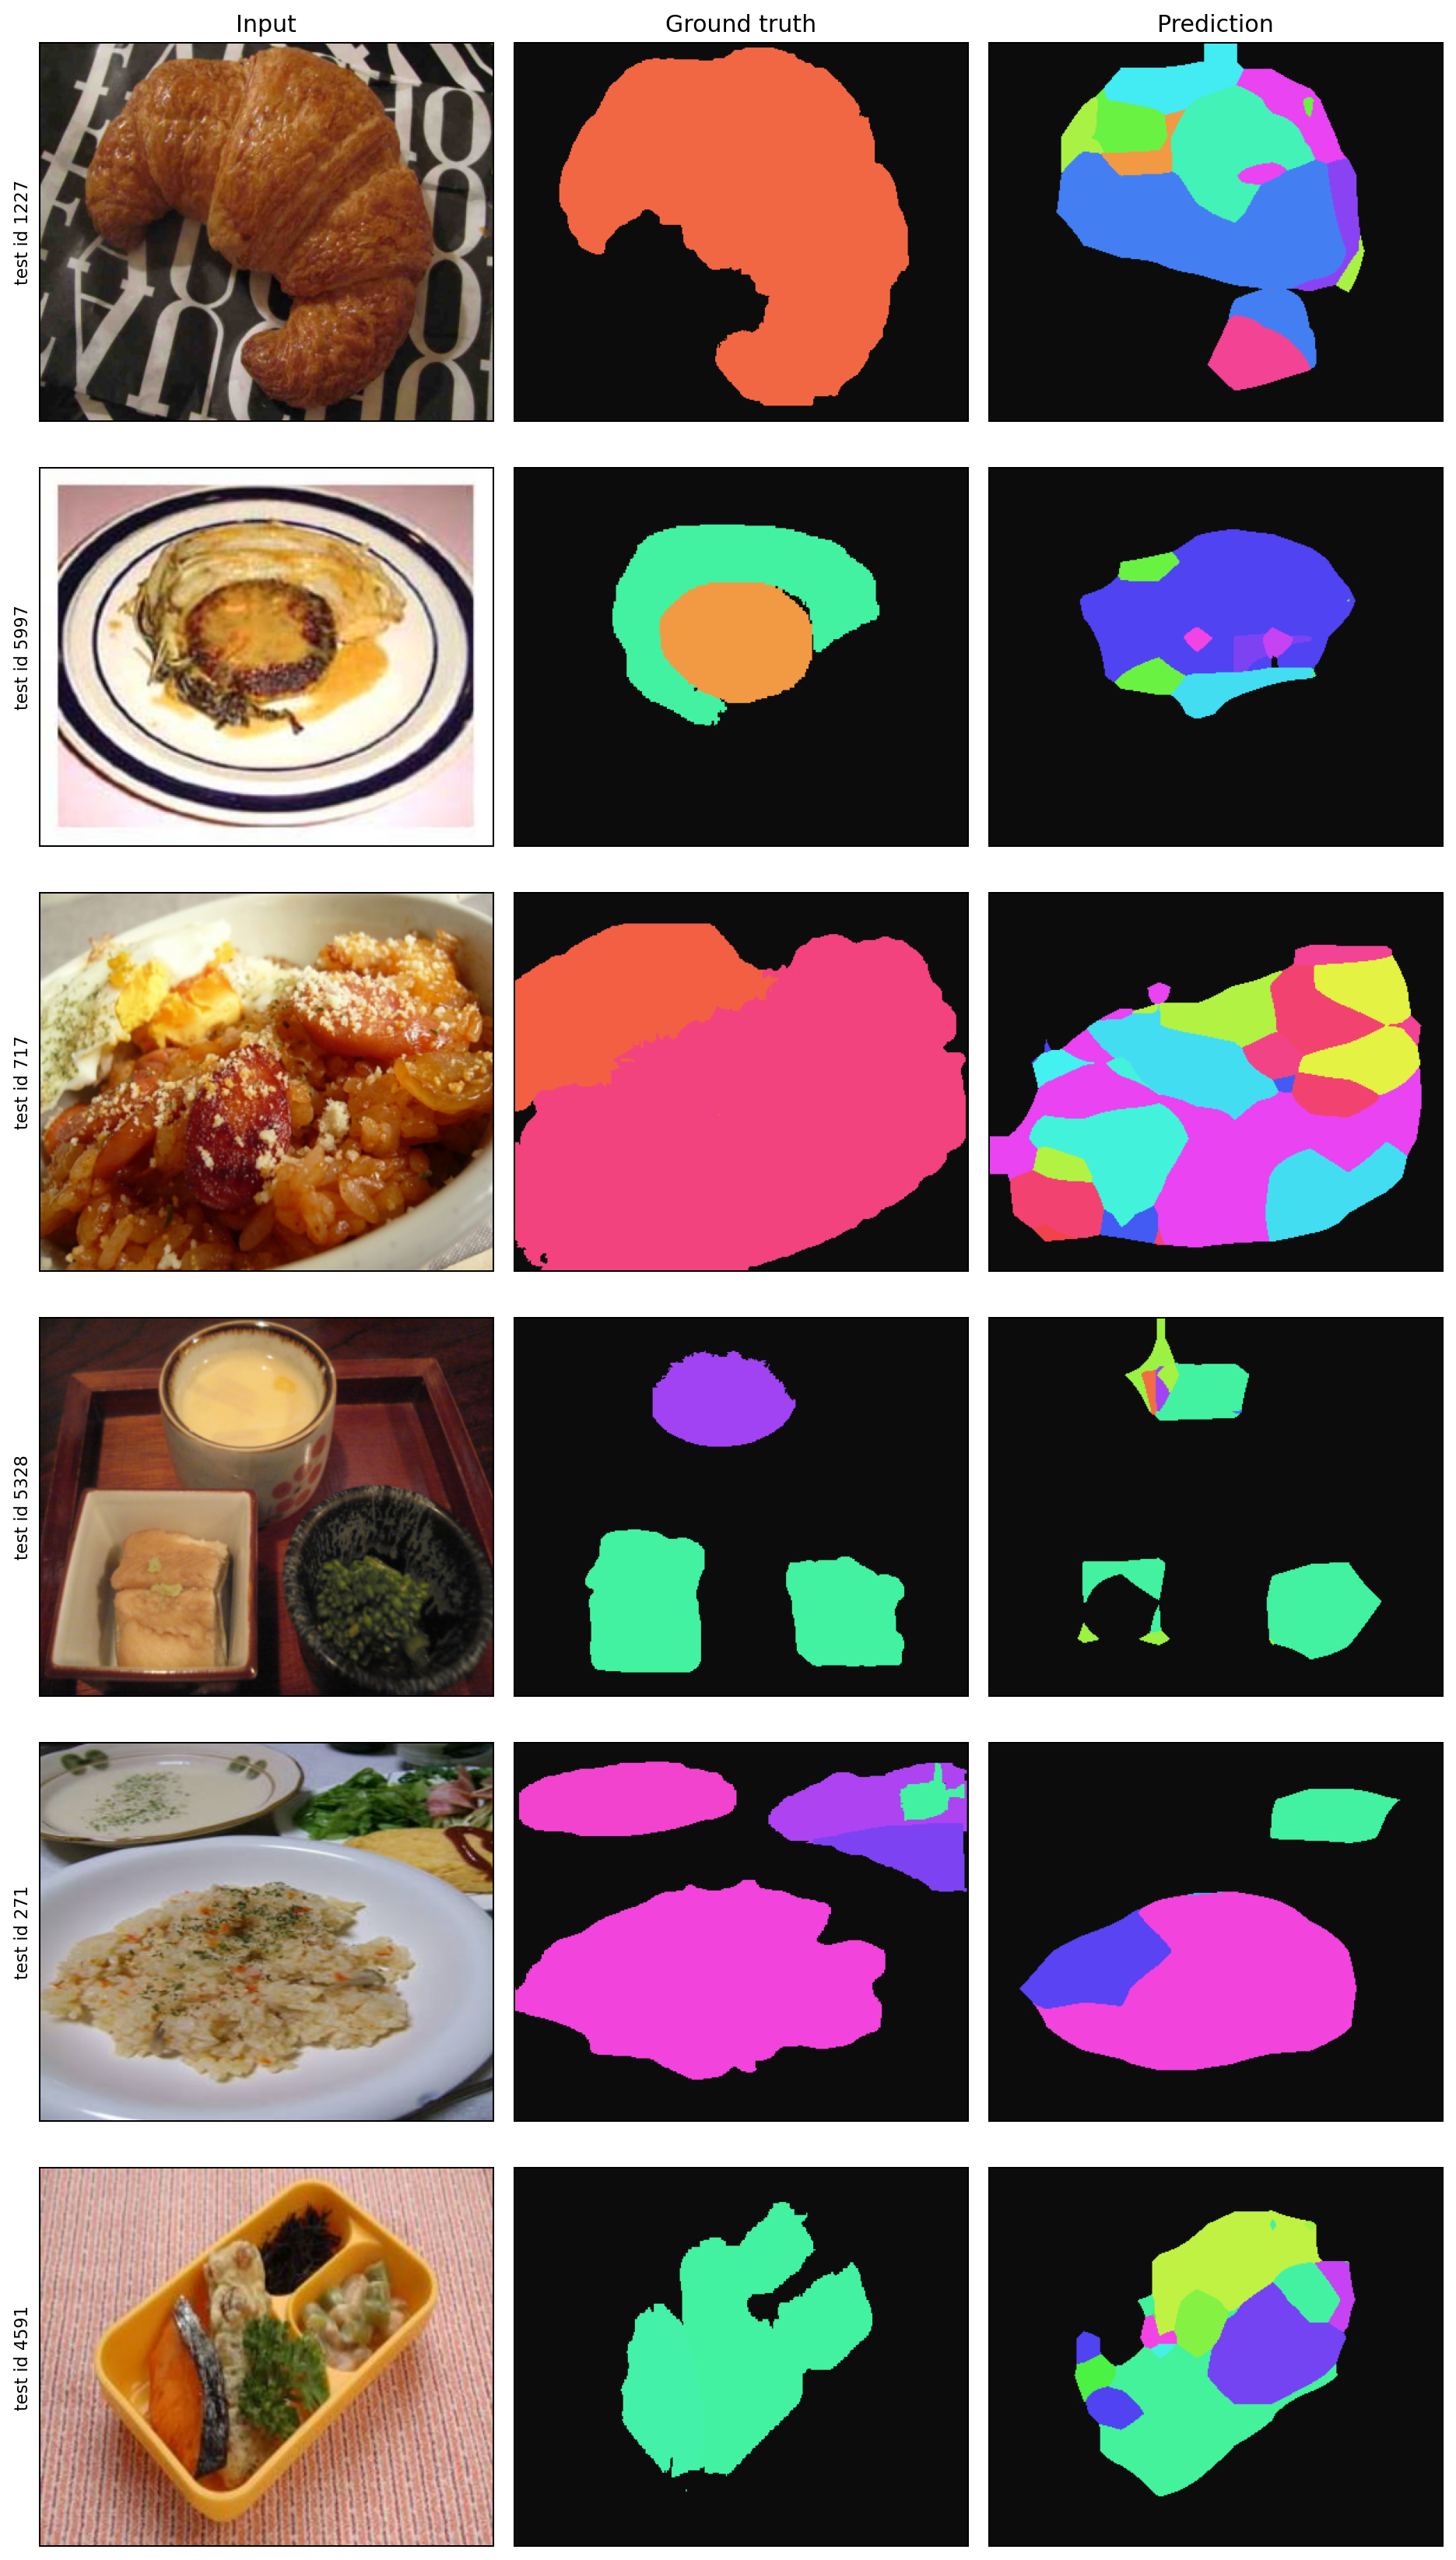

VGG16-FCN: all 103 classes plus a normalized detail view of the 25 most-supported classes


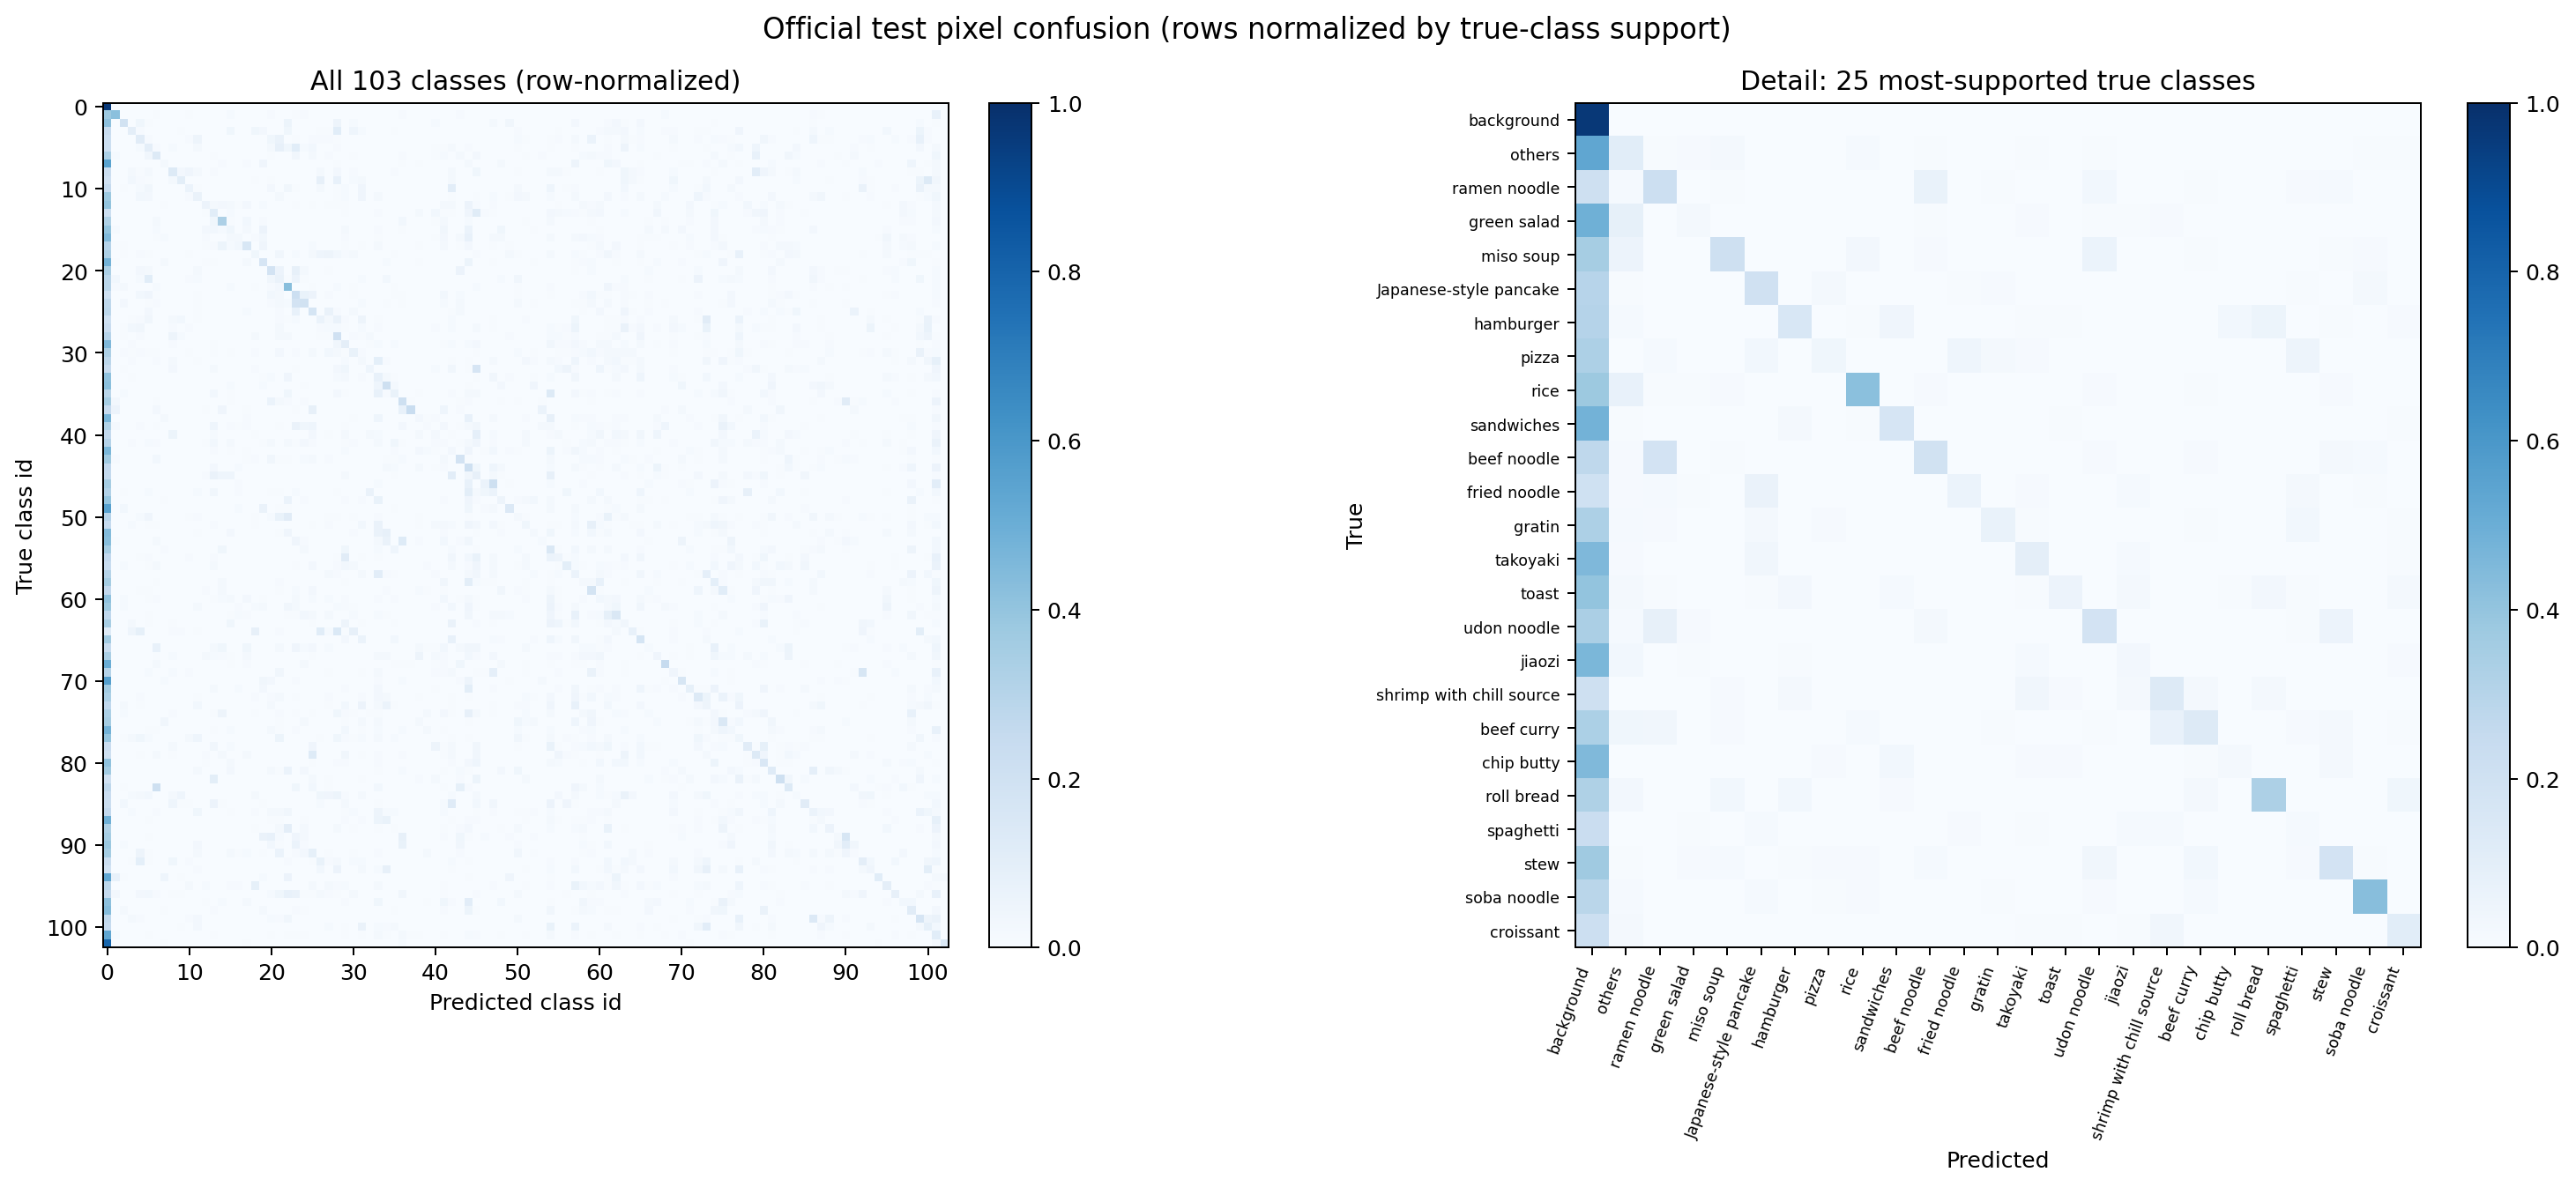

VGG16-FCN: input / ground truth / prediction examples


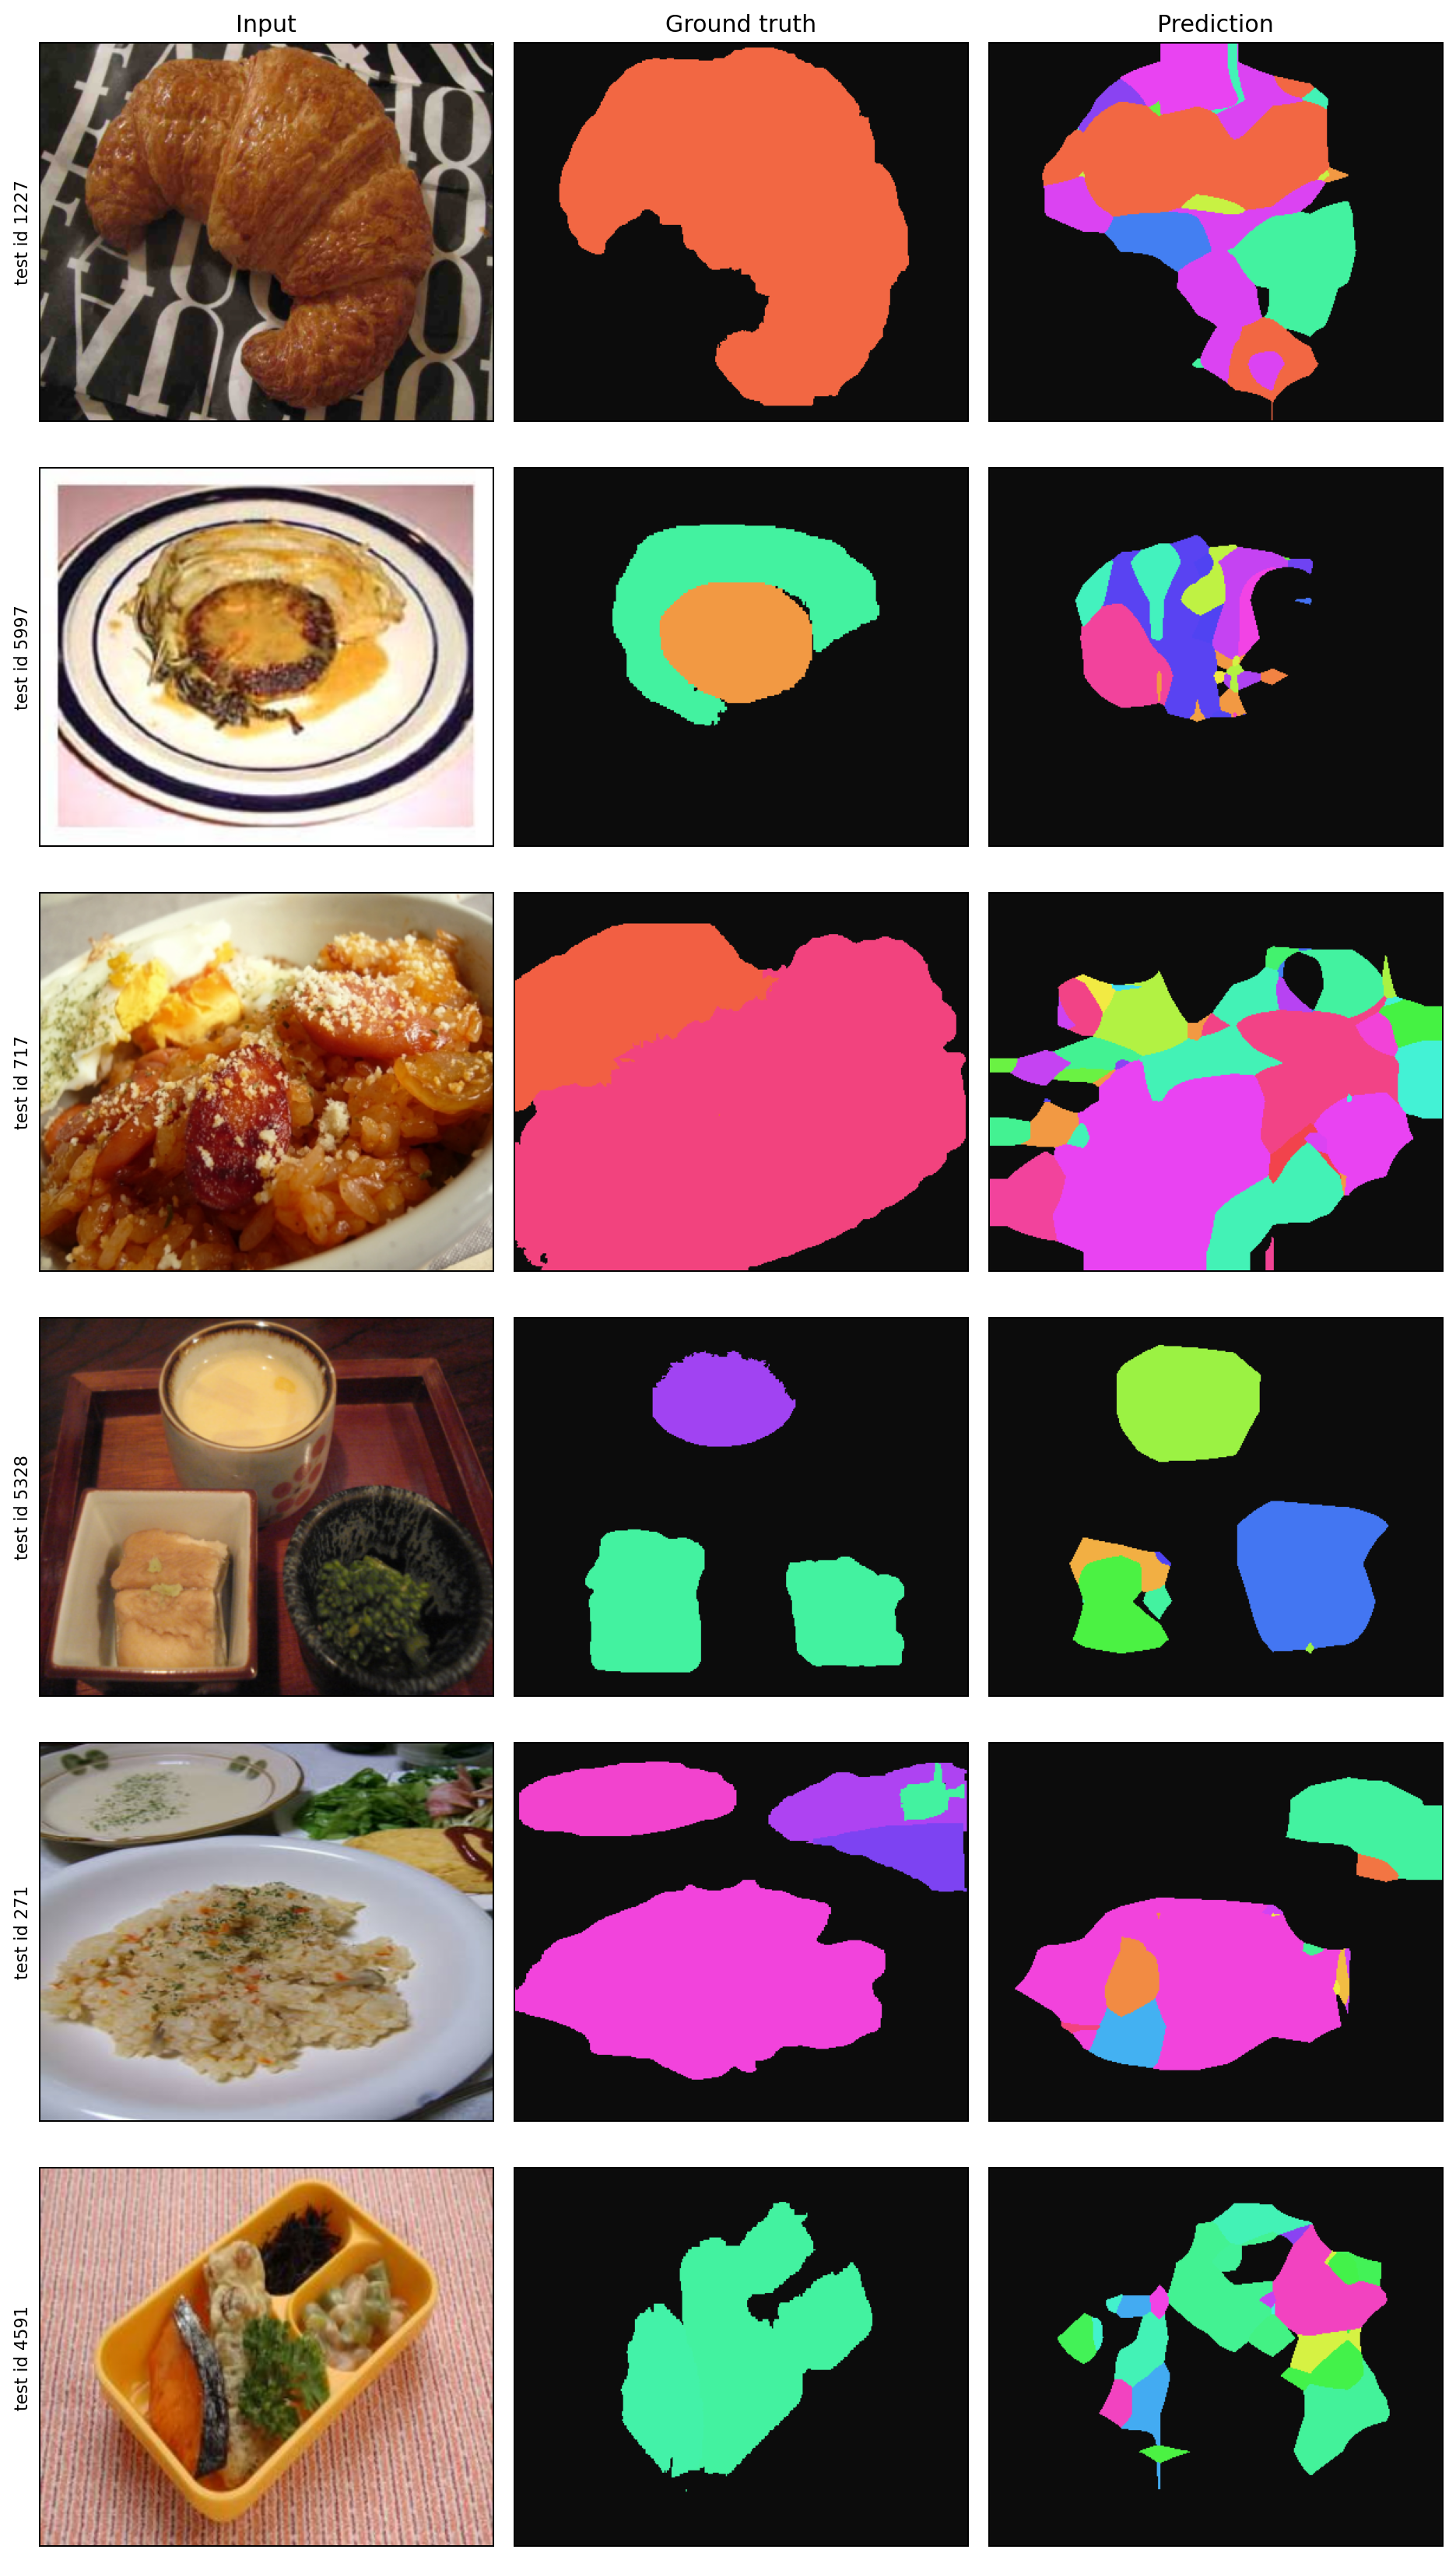

In [7]:
for key, label in MODELS.items():
    print(f"{label}: all 103 classes plus a normalized detail view of the 25 most-supported classes")
    display(Image(filename=str(ROOT / "outputs" / key / "test_confusion_matrix.png"), width=900))
    print(f"{label}: input / ground truth / prediction examples")
    display(Image(filename=str(ROOT / "outputs" / key / "test_predictions.png"), width=900))


## 8. Artifact integrity checks

This final cell confirms that both runs completed and that the comparison table is derived from the same result JSON files. SHA-256 values make the exact checkpoints and metric files identifiable during group integration.


In [8]:
required = []
for key in MODELS:
    run = ROOT / "outputs" / key
    completed = json.loads((run / "COMPLETED.json").read_text(encoding="utf-8"))
    assert completed["status"] == "complete"
    required += [run / "best.pt", run / "history.csv", run / "test_metrics.json",
                 run / "test_confusion_matrix.csv", run / "test_per_class_metrics.csv"]
for path in required:
    assert path.exists() and path.stat().st_size > 0, path
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    print(f"{path.relative_to(ROOT)}  {path.stat().st_size:,} bytes  sha256={digest[:16]}...")
print("All baseline artifacts verified.")


outputs\resnet50_fcn\best.pt  396,433,985 bytes  sha256=a0fc021b83e69175...
outputs\resnet50_fcn\history.csv  10,696 bytes  sha256=86f496ce2ca3a32b...
outputs\resnet50_fcn\test_metrics.json  468 bytes  sha256=a4cd472559acc43c...
outputs\resnet50_fcn\test_confusion_matrix.csv  35,698 bytes  sha256=b71d7f231ed49cd9...
outputs\resnet50_fcn\test_per_class_metrics.csv  8,753 bytes  sha256=0d4b1f9583e92e25...


outputs\vgg16_fcn\best.pt  191,106,019 bytes  sha256=de17f06f5202ea82...
outputs\vgg16_fcn\history.csv  10,678 bytes  sha256=e635abea439329c9...
outputs\vgg16_fcn\test_metrics.json  469 bytes  sha256=32b571726ae3b4d0...
outputs\vgg16_fcn\test_confusion_matrix.csv  40,027 bytes  sha256=208bbfe3f714a1a9...
outputs\vgg16_fcn\test_per_class_metrics.csv  8,818 bytes  sha256=0e8ea674a41b089f...
All baseline artifacts verified.


## 9. Group-integration note

Merge the method/protocol, comparison table, and selected figures into the whole-group notebook. In the final Results and Discussion, compare these fixed baselines against the improved model using the same held-out split and metrics. Do not use the official test set to make further model choices.
